In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Outcome"] = data.target

print("Dataset shape:", df.shape)
print("Target mapping: 0 = Malignant, 1 = Benign")
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (569, 31)
Target mapping: 0 = Malignant, 1 = Benign

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

In [4]:
summary_statistics = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Standard Deviation": df.std(),
    "Minimum": df.min(),
    "Maximum": df.max()
})
print("Summary statistics:")
display(summary_statistics)

print("Descriptive statistics:")
display(df.describe().T)

Summary statistics:


,Mean,Median,Standard Deviation,Minimum,Maximum
mean radius,14.127292,13.370000,3.524049,6.981000,28.11000
mean texture,19.289649,18.840000,4.301036,9.710000,39.28000
mean perimeter,91.969033,86.240000,24.298981,43.790000,188.50000
mean area,654.889104,551.100000,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.095870,0.014064,0.052630,0.16340
mean compactness,0.104341,0.092630,0.052813,0.019380,0.34540
mean concavity,0.088799,0.061540,0.079720,0.000000,0.42680
mean concave points,0.048919,0.033500,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.179200,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.061540,0.007060,0.049960,0.09744


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
missing_values = df.isnull().sum()
print("Missing values by column:")
display(missing_values[missing_values > 0].to_frame("Missing Values"))
print("Total missing values:", int(missing_values.sum()))

for column in df.drop(columns=["Outcome"]).columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].median())

print("Total missing values after handling:", int(df.isnull().sum().sum()))

Missing values by column:


,Missing Values


Total missing values: 0
Total missing values after handling: 0


In [6]:
duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Duplicate rows: 0
No duplicates found.


In [7]:
X_outlier = df.drop(columns=["Outcome"])
Q1 = X_outlier.quantile(0.25)
Q3 = X_outlier.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X_outlier < (Q1 - 1.5 * IQR)) | (X_outlier > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Potential outliers by feature:")
display(outlier_counts.to_frame("Outlier Count"))

print("Decision: potential medical outliers are retained because extreme measurements may represent genuine observations.")

Potential outliers by feature:


,Outlier Count
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


Decision: potential medical outliers are retained because extreme measurements may represent genuine observations.


/tmp/ipykernel_500/3174292703.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X_outlier[col] for col in X_outlier.columns], labels=X_outlier.columns)


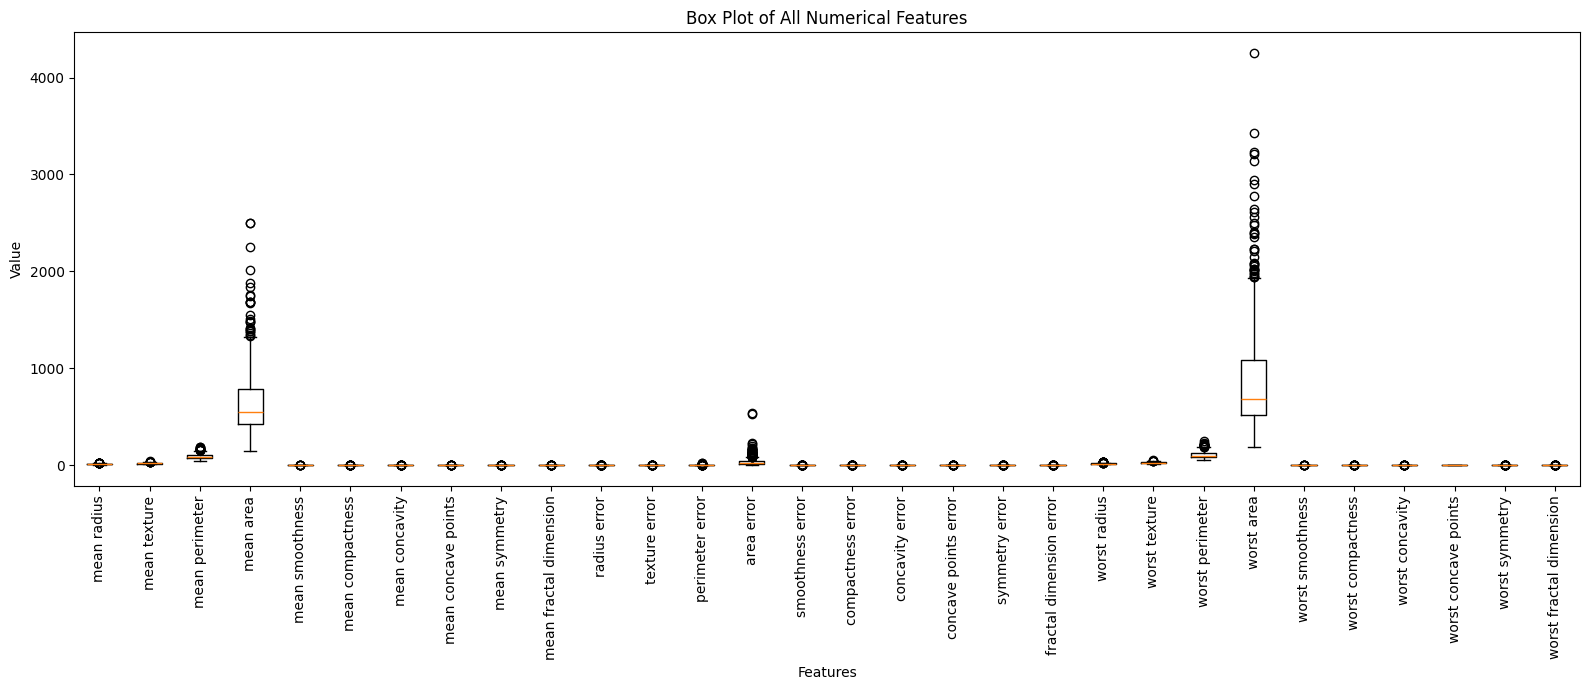

In [8]:
plt.figure(figsize=(16, 7))
plt.boxplot([X_outlier[col] for col in X_outlier.columns], labels=X_outlier.columns)
plt.xticks(rotation=90)
plt.title("Box Plot of All Numerical Features")
plt.xlabel("Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

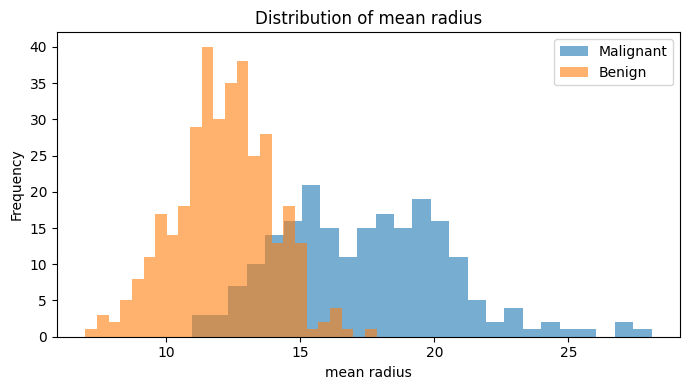

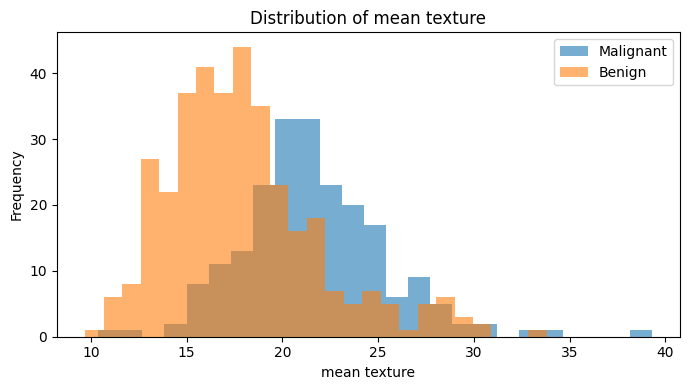

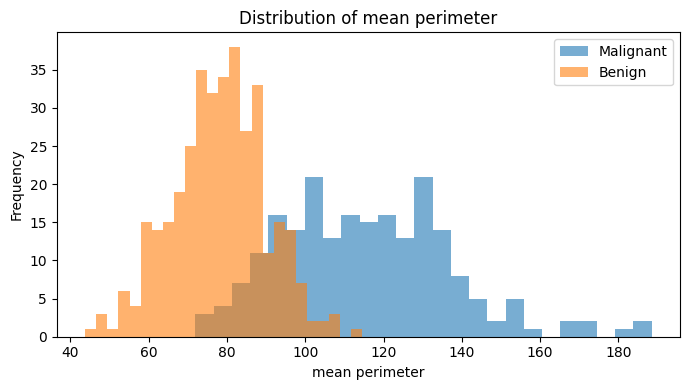

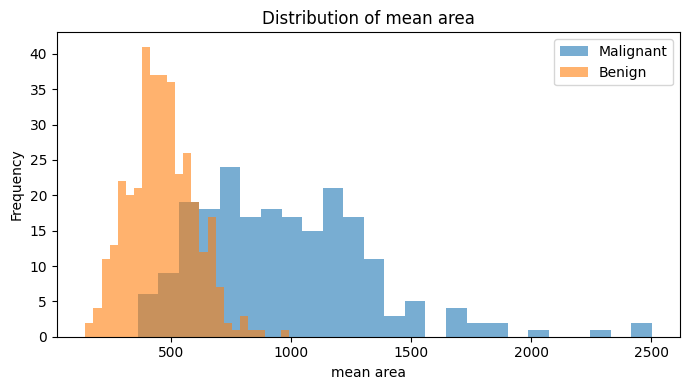

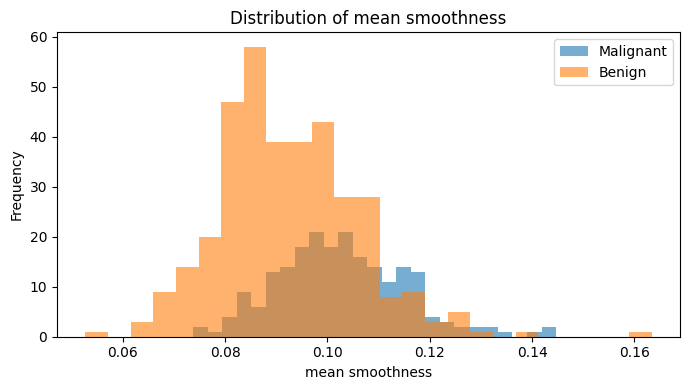

In [9]:
key_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]

for feature in key_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df.loc[df["Outcome"] == 0, feature], bins=25, alpha=0.6, label="Malignant")
    plt.hist(df.loc[df["Outcome"] == 1, feature], bins=25, alpha=0.6, label="Benign")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

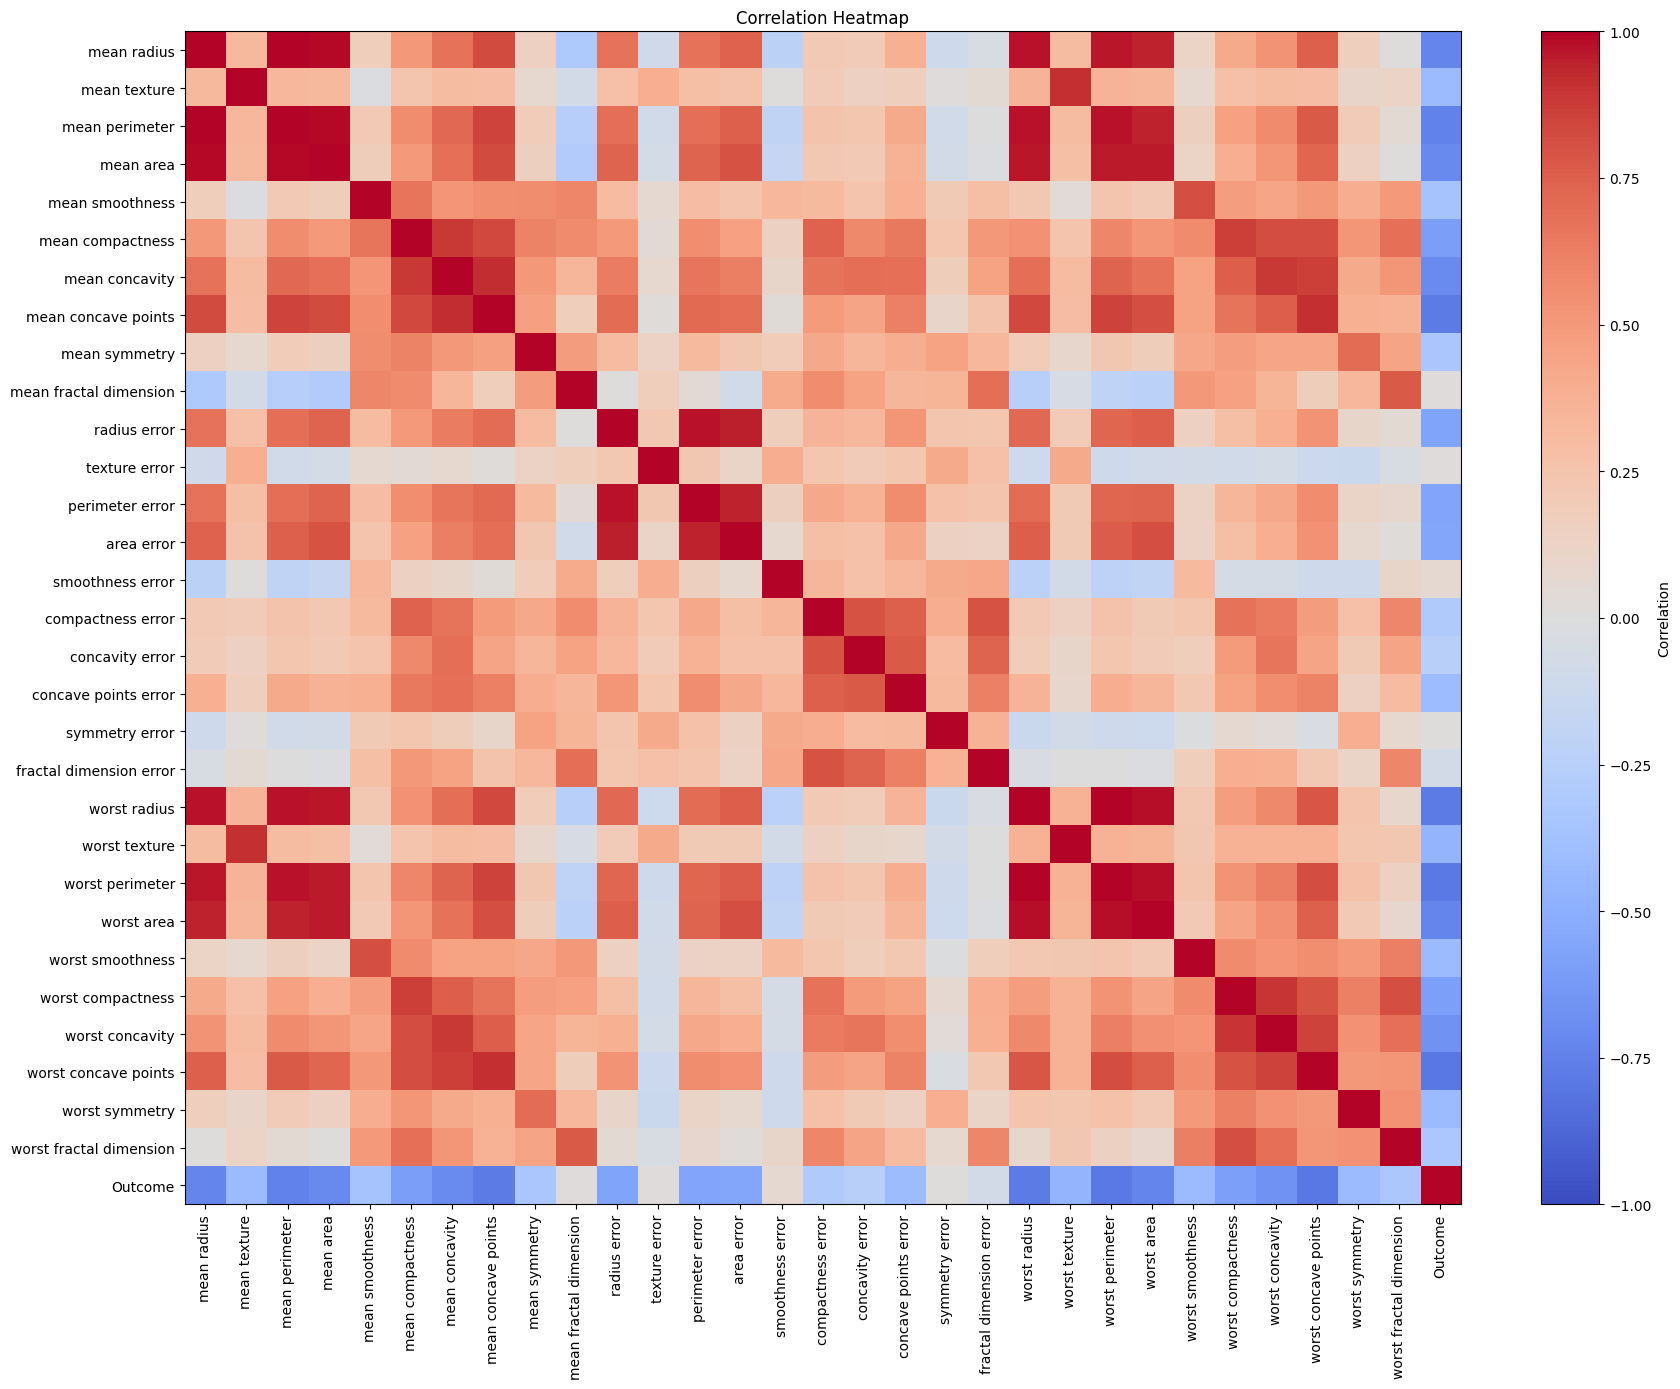

Correlation matrix:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
mean radius,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,0.68,-0.10,0.67,0.74,-0.22,0.21,0.19,0.38,-0.10,-0.04,0.97,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01,-0.73
mean texture,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,0.28,0.39,0.28,0.26,0.01,0.19,0.14,0.16,0.01,0.05,0.35,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12,-0.42
mean perimeter,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,0.69,-0.09,0.69,0.74,-0.20,0.25,0.23,0.41,-0.08,-0.01,0.97,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05,-0.74
mean area,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,0.73,-0.07,0.73,0.80,-0.17,0.21,0.21,0.37,-0.07,-0.02,0.96,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00,-0.71
mean smoothness,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,0.30,0.07,0.30,0.25,0.33,0.32,0.25,0.38,0.20,0.28,0.21,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50,-0.36
mean compactness,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,0.50,0.05,0.55,0.46,0.14,0.74,0.57,0.64,0.23,0.51,0.54,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69,-0.60
mean concavity,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,0.63,0.08,0.66,0.62,0.10,0.67,0.69,0.68,0.18,0.45,0.69,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51,-0.70
mean concave points,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,0.70,0.02,0.71,0.69,0.03,0.49,0.44,0.62,0.10,0.26,0.83,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37,-0.78
mean symmetry,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,0.30,0.13,0.31,0.22,0.19,0.42,0.34,0.39,0.45,0.33,0.19,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44,-0.33
mean fractal dimension,-0.31,-0.08,-0.26,-0.28,0.58,0.57,0.34,0.17,0.48,1.00,0.00,0.16,0.04,-0.09,0.40,0.56,0.45,0.34,0.35,0.69,-0.25,-0.05,-0.21,-0.23,0.50,0.46,0.35,0.18,0.33,0.77,0.01


In [10]:
correlation_matrix = df.corr()
plt.figure(figsize=(18, 14))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation matrix:")
display(correlation_matrix.round(2))

Class distribution:


,Class,Count,Percentage
0,Malignant,212,37.258348
1,Benign,357,62.741652


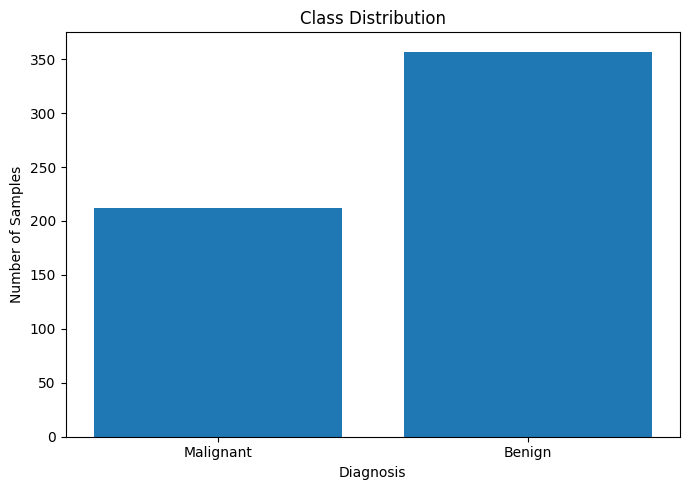

Interpretation: the dataset has moderate class imbalance, so accuracy alone should not be used to judge medical classification performance.


In [11]:
class_counts = df["Outcome"].value_counts().sort_index()
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": ["Malignant", "Benign"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "Percentage": [class_percentages.get(0, 0), class_percentages.get(1, 0)]
})

print("Class distribution:")
display(class_distribution)

plt.figure(figsize=(7, 5))
plt.bar(["Malignant", "Benign"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

print("Interpretation: the dataset has moderate class imbalance, so accuracy alone should not be used to judge medical classification performance.")

In [12]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (455, 30)
Testing set: (114, 30)

Training class proportions:
Outcome
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Testing class proportions:
Outcome
0    0.368421
1    0.631579
Name: proportion, dtype: float64


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")
print("Scaler fitted only on training data to avoid data leakage.")

Feature standardization completed.
Scaler fitted only on training data to avoid data leakage.


In [14]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision_malignant = precision_score(y_test, y_pred, pos_label=0)
recall_malignant = recall_score(y_test, y_pred, pos_label=0)
f1_malignant = f1_score(y_test, y_pred, pos_label=0)
precision_benign = precision_score(y_test, y_pred, pos_label=1)
recall_benign = recall_score(y_test, y_pred, pos_label=1)
f1_benign = f1_score(y_test, y_pred, pos_label=1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Malignant Precision: {precision_malignant:.4f}")
print(f"Malignant Recall: {recall_malignant:.4f}")
print(f"Malignant F1-score: {f1_malignant:.4f}")
print(f"Benign Precision: {precision_benign:.4f}")
print(f"Benign Recall: {recall_benign:.4f}")
print(f"Benign F1-score: {f1_benign:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

Accuracy: 0.9825
Malignant Precision: 0.9762
Malignant Recall: 0.9762
Malignant F1-score: 0.9762
Benign Precision: 0.9861
Benign Recall: 0.9861
Benign F1-score: 0.9861

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



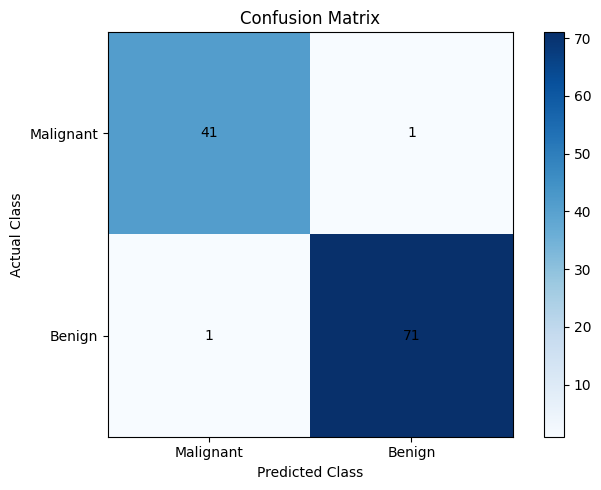

Confusion Matrix:
[[41  1]
 [ 1 71]]

For medical diagnosis, missed malignant cases (malignant predicted as benign) are especially important to monitor.


In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)
print("\nFor medical diagnosis, missed malignant cases (malignant predicted as benign) are especially important to monitor.")

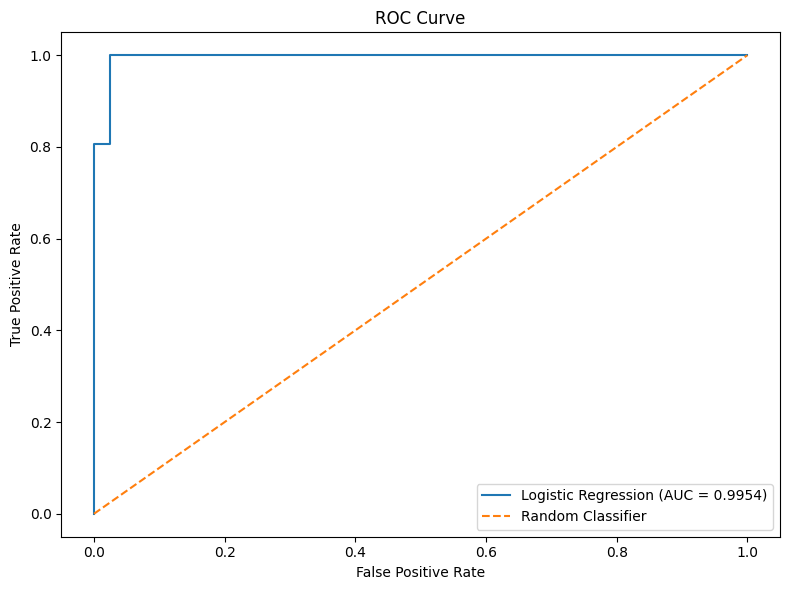

ROC-AUC Score: 0.9954


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [18]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy", "Malignant Precision", "Malignant Recall", "Malignant F1-score",
        "Benign Precision", "Benign Recall", "Benign F1-score", "ROC-AUC"
    ],
    "Score": [
        accuracy, precision_malignant, recall_malignant, f1_malignant,
        precision_benign, recall_benign, f1_benign, auc_score
    ]
})
results["Score"] = results["Score"].round(4)

print("Final Model Results:")
display(results)

Final Model Results:


,Metric,Score
0,Accuracy,0.9825
1,Malignant Precision,0.9762
2,Malignant Recall,0.9762
3,Malignant F1-score,0.9762
4,Benign Precision,0.9861
5,Benign Recall,0.9861
6,Benign F1-score,0.9861
7,ROC-AUC,0.9954


L2 Regularization Comparison:


/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

,C,Accuracy,Malignant Recall,Malignant F1,ROC-AUC
0,0.01,0.9474,0.8810,0.9250,0.9950
1,0.10,0.9737,0.9524,0.9639,0.9957
2,1.00,0.9825,0.9762,0.9762,0.9954
3,10.00,0.9649,0.9524,0.9524,0.9934
4,100.00,0.9474,0.9524,0.9302,0.9861


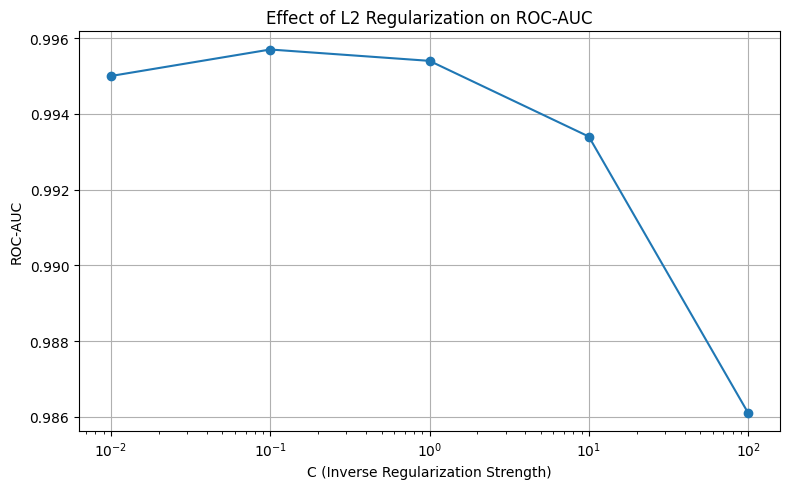

In [19]:
C_values = [0.01, 0.1, 1, 10, 100]
regularization_results = []

for C in C_values:
    model = LogisticRegression(C=C, penalty="l2", max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]
    regularization_results.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, pred),
        "Malignant Recall": recall_score(y_test, pred, pos_label=0),
        "Malignant F1": f1_score(y_test, pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

regularization_results = pd.DataFrame(regularization_results).round(4)
print("L2 Regularization Comparison:")
display(regularization_results)

plt.figure(figsize=(8, 5))
plt.semilogx(regularization_results["C"], regularization_results["ROC-AUC"], marker="o")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("ROC-AUC")
plt.title("Effect of L2 Regularization on ROC-AUC")
plt.grid(True)
plt.tight_layout()
plt.show()

Top 15 features by absolute coefficient:


,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


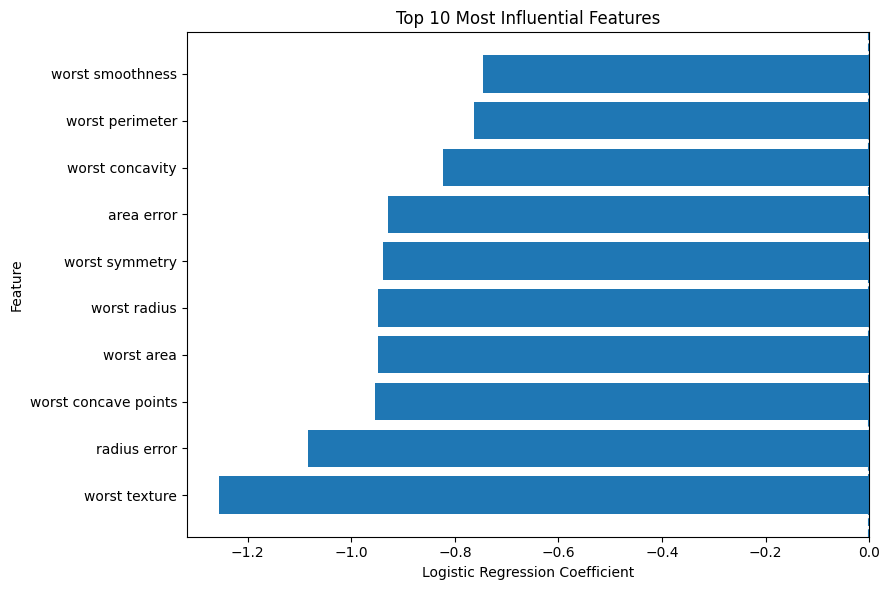

Positive coefficient -> greater tendency toward class 1 (Benign).
Negative coefficient -> greater tendency toward class 0 (Malignant).


In [20]:
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})
coefficient_df["Absolute Coefficient"] = coefficient_df["Coefficient"].abs()
coefficient_df = coefficient_df.sort_values("Absolute Coefficient", ascending=False)

print("Top 15 features by absolute coefficient:")
display(coefficient_df.head(15))

top_coefficients = coefficient_df.head(10).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.axvline(0, linestyle="--")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features")
plt.tight_layout()
plt.show()

print("Positive coefficient -> greater tendency toward class 1 (Benign).")
print("Negative coefficient -> greater tendency toward class 0 (Malignant).")

In [21]:
print("FINAL CONCLUSION")
print("=" * 80)
print("The Breast Cancer Wisconsin (Diagnostic) dataset was explored and preprocessed.")
print("An 80/20 stratified split and training-only standardization were applied.")
print("Logistic Regression was trained and evaluated using accuracy, precision, recall,")
print("F1-score, confusion matrix, ROC-AUC, regularization comparison, and coefficients.")
print("For medical diagnosis, malignant recall is particularly important because")
print("false-negative malignant predictions can have serious consequences.")
print("=" * 80)
print(f"Final Accuracy: {accuracy:.4f}")
print(f"Final Malignant Recall: {recall_malignant:.4f}")
print(f"Final ROC-AUC: {auc_score:.4f}")

FINAL CONCLUSION
The Breast Cancer Wisconsin (Diagnostic) dataset was explored and preprocessed.
An 80/20 stratified split and training-only standardization were applied.
Logistic Regression was trained and evaluated using accuracy, precision, recall,
F1-score, confusion matrix, ROC-AUC, regularization comparison, and coefficients.
For medical diagnosis, malignant recall is particularly important because
false-negative malignant predictions can have serious consequences.
Final Accuracy: 0.9825
Final Malignant Recall: 0.9762
Final ROC-AUC: 0.9954
